In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [300]:
df=pd.read_csv('cleaned_data.csv')
df.head(3)

,company,education,industry,jobdescription,jobid,joblocation_address,jobtitle,numberofpositions,site_name,skills,min_pay,max_pay,min_exp,max_exp,avg_pay,avg_exp,day,month,year
0,MM Media Pvt Ltd,UG: B.Tech/B.E. - Any Specialization PG:Any Po...,Media / Entertainment / Internet,Job Description Send me Jobs like this Quali...,210516002263,Chennai,Walkin Data Entry Operator (night Shift),NaN,NaN,ITES,150000.0,225000.0,0.0,1.0,187500.0,0.5,21.0,5.0,2016.0
1,find live infotech,UG: B.Tech/B.E. - Any Specialization PG:MBA/PG...,Advertising / PR / MR / Event Management,Job Description Send me Jobs like this Quali...,210516002391,Chennai,Work Based Onhome Based Part Time.,60.0,NaN,Marketing,150000.0,250000.0,0.0,0.0,200000.0,0.0,21.0,5.0,2016.0
2,Softtech Career Infosystem Pvt. Ltd,UG: Any Graduate - Any Specialization PG:Any P...,IT-Software / Software Services,Job Description Send me Jobs like this - as ...,101016900534,Bengaluru,Pl/sql Developer - SQL,NaN,NaN,IT Software - Application Programming,NaN,NaN,4.0,8.0,NaN,6.0,13.0,10.0,2016.0


#### Let's perform some descriptive analysis

In [301]:
df.describe().T # Transpose

,count,mean,std,min,25%,50%,75%,max
jobid,22000.0,1.561171e+11,9.423956e+10,1.011600e+10,6.121650e+10,1.602169e+11,2.502166e+11,3.112155e+11
numberofpositions,4464.0,4.511694e+01,1.861972e+02,1.000000e+00,2.000000e+00,4.000000e+00,1.000000e+01,2.000000e+03
min_pay,5075.0,4.155029e+05,5.520506e+05,2.000000e+00,1.250000e+05,2.250000e+05,5.000000e+05,5.500000e+06
max_pay,4940.0,7.342964e+05,7.559780e+05,1.000000e+00,3.000000e+05,5.000000e+05,9.000000e+05,8.000000e+06
min_exp,21885.0,3.600960e+00,3.100464e+00,0.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,2.600000e+01
max_exp,21885.0,7.117523e+00,3.924028e+00,0.000000e+00,5.000000e+00,7.000000e+00,9.000000e+00,3.000000e+01
avg_pay,4755.0,6.008572e+05,6.426872e+05,9.000000e+00,2.500000e+05,3.750000e+05,7.000000e+05,6.500000e+06
avg_exp,21885.0,5.359241e+00,3.444405e+00,0.000000e+00,3.000000e+00,4.500000e+00,7.000000e+00,2.800000e+01
day,21977.0,1.884993e+01,9.751744e+00,1.000000e+00,9.000000e+00,2.200000e+01,2.900000e+01,3.100000e+01
month,21977.0,7.224189e+00,4.062145e+00,1.000000e+00,3.000000e+00,8.000000e+00,1.100000e+01,1.200000e+01


In [302]:
df.describe(include=['O']) # For categorical cols
# top --> most freq value
# freq --> frequency of the top value

,company,education,industry,jobdescription,joblocation_address,jobtitle,site_name,skills
count,21996,20004,21995,21996,21499,22000,3987,21472
unique,8469,2355,63,21063,2329,17564,1,45
top,Indian Institute of Technology Bombay,"UG: Any Graduate - Any Specialization, Graduat...",IT-Software / Software Services,Job Description Send me Jobs like this Adver...,Bengaluru/Bangalore,Business Development Executive,www.naukri.com,IT Software - Application Programming
freq,403,2015,9216,121,3775,93,3987,5989


In [303]:
categorical_cols = [col for col in df.columns if df[col].dtype=='object'] 
categorical_cols

['company',
 'education',
 'industry',
 'jobdescription',
 'joblocation_address',
 'jobtitle',
 'site_name',
 'skills']

In [304]:
numerical_cols = [col for col in df.columns if df[col].dtype !='object'] 
numerical_cols

['jobid',
 'numberofpositions',
 'min_pay',
 'max_pay',
 'min_exp',
 'max_exp',
 'avg_pay',
 'avg_exp',
 'day',
 'month',
 'year']

In [305]:
df2= df[numerical_cols]

In [306]:
df2

,jobid,numberofpositions,min_pay,max_pay,min_exp,max_exp,avg_pay,avg_exp,day,month,year
0,210516002263,NaN,150000.0,225000.0,0.0,1.0,187500.0,0.5,21.0,5.0,2016.0
1,210516002391,60.0,150000.0,250000.0,0.0,0.0,200000.0,0.0,21.0,5.0,2016.0
2,101016900534,NaN,NaN,NaN,4.0,8.0,NaN,6.0,13.0,10.0,2016.0
3,81016900536,NaN,NaN,NaN,11.0,15.0,NaN,13.0,13.0,10.0,2016.0
4,120916002122,4.0,NaN,NaN,6.0,8.0,NaN,7.0,13.0,10.0,2016.0
...,...,...,...,...,...,...,...,...,...,...,...
21995,241116007152,2.0,NaN,NaN,9.0,13.0,NaN,11.0,25.0,11.0,2016.0
21996,241116001104,NaN,850000.0,1400000.0,3.0,5.0,1125000.0,4.0,24.0,11.0,2016.0
21997,251116900644,NaN,NaN,NaN,2.0,4.0,NaN,3.0,25.0,11.0,2016.0
21998,231116901329,NaN,NaN,NaN,7.0,12.0,NaN,9.5,27.0,11.0,2016.0


Text(0.5, 1.0, 'Correlation Heatmap of job market analysis of India')

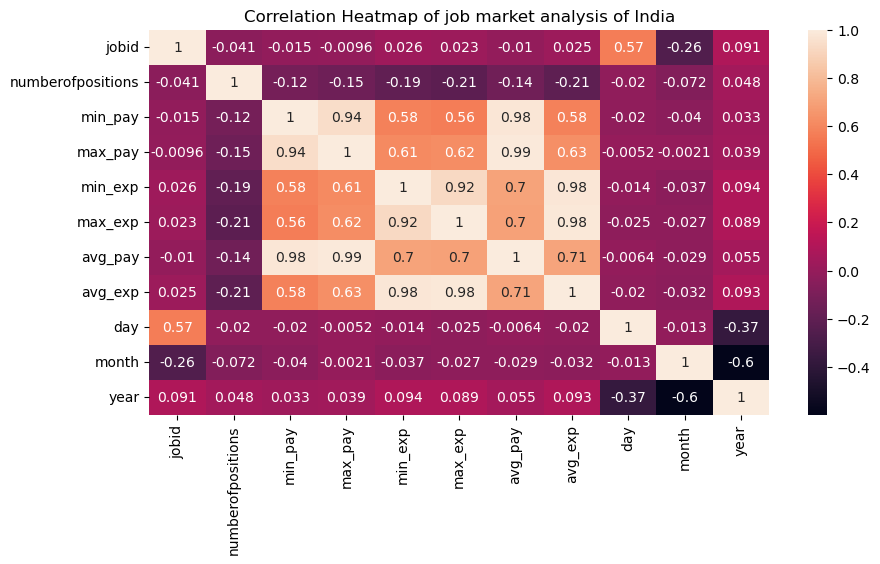

In [307]:
plt.figure( figsize=(10,5) )
sns.heatmap(df2.corr(), annot=True)
plt.title('Correlation Heatmap of job market analysis of India')

In [308]:
df2.corr()['min_pay']

jobid               -0.015443
numberofpositions   -0.119206
min_pay              1.000000
max_pay              0.939651
min_exp              0.580995
max_exp              0.563455
avg_pay              0.979530
avg_exp              0.580557
day                 -0.020086
month               -0.039722
year                 0.033235
Name: min_pay, dtype: float64

#### Find companies with max number of positions

In [309]:
df['numberofpositions'].max()

2000.0

In [310]:
df[df['numberofpositions']==200]

,company,education,industry,jobdescription,jobid,joblocation_address,jobtitle,numberofpositions,site_name,skills,min_pay,max_pay,min_exp,max_exp,avg_pay,avg_exp,day,month,year
1818,Gratitude India,UG: Any Graduate - Any Specialization PG:Any P...,BPO / Call Centre / ITES,Job Description Send me Jobs like this Immed...,270516600380,"Bengaluru/Bangalore , Delhi/NCR(National Capit...","Customer Service Executive, Bpo Executive, Tec...",200.0,NaN,ITES,NaN,NaN,0.0,4.0,NaN,2.0,26.0,5.0,2016.0
1825,GI Staffing Services Pvt. Ltd,UG: Any Graduate - Any Specialization PG:Any P...,Internet / Ecommerce,Job Description Send me Jobs like this We ar...,140616601784,Delhi NCR,Urgent Openings in Sales for Paytm,200.0,NaN,Sales,NaN,NaN,0.0,3.0,NaN,1.5,27.0,5.0,2016.0
4218,DESIROUS GLOBAL CONSULTING PRIVATE LIMITED hir...,UG: Any Graduate - Any Specialization PG:Any P...,BPO / Call Centre / ITES,Job Description Send me Jobs like this Email...,301115063455,Chennai,"Opening For Non Voice ,E Mail Support with Lea...",200.0,NaN,ITES,100000.0,250000.0,0.0,3.0,175000.0,1.5,30.0,11.0,2015.0
4308,Natural Sourcing hiring for international mnc,UG: Graduation Not Required PG:Post Graduation...,BPO / Call Centre / ITES,Job Description Send me Jobs like this urgen...,271115000048,"Bengaluru/Bangalore , Mumbai , Chennai , Hyder...",Call Center Executive,200.0,NaN,ITES,200000.0,700000.0,0.0,5.0,450000.0,2.5,27.0,11.0,2015.0
4631,MaxIT Global solutions Pvt Ltd,UG: Any Graduate - Any Specialization PG:Any P...,BPO / Call Centre / ITES,Job Description Send me Jobs like this Role:...,271115000234,Chennai,International Voice Process for Freshers,200.0,NaN,ITES,NaN,NaN,0.0,1.0,NaN,0.5,27.0,11.0,2015.0
5076,Kamms management Consultants hiring for Govt D...,UG: Any Graduate - Any Specialization PG:Any P...,Fresher / Trainee / Entry Level,Job Description Send me Jobs like this Contr...,171115007332,"Chennai , Coimbatore , Cuddalore , Erode , Hos...",Data Entry Operators - Govt Departments in All...,200.0,NaN,Executive Assistant,100000.0,125000.0,0.0,5.0,112500.0,2.5,24.0,11.0,2015.0
8388,Radvision World Consultancy,"UG: B.Sc - Biology, Nursing PG:M.Sc - Biology,...",Medical / Healthcare / Hospitals,Job Description Send me Jobs like this Govt ...,300316008618,Delhi/NCR(National Capital Region),"Excellent Opportunity For Nurses in Germany , ...",200.0,NaN,Medical,NaN,NaN,2.0,7.0,NaN,4.5,4.0,5.0,2016.0
20910,Orion Security Solutions Pvt. Ltd.,NaN,Other,Job Description Send me Jobs like this Job S...,231216004367,"Bengaluru, Mumbai, Chennai, Pune, Hyderabad, D...",Fire Engineers for UAE,200.0,www.naukri.com,NaN,NaN,NaN,2.0,3.0,NaN,2.5,23.0,12.0,2016.0


In [311]:
company_df= df['company'].value_counts().reset_index() # Getting a sorted df in descending order bcz of value_counts()
# Each row is not a company — it's a job post by a company.
# so, value_counts() tells the Number of job postings per company.

In [312]:
company_df

,company,count
0,Indian Institute of Technology Bombay,403
1,Confidential,393
2,National Institute of Industrial Engineering,185
3,Oracle India Pvt. Ltd.,151
4,JPMorgan Chase,135
...,...,...
8464,Bello Jewels Pvt Ltd,1
8465,ITG Telematics Pvt Ltd,1
8466,Genuine Management Services Pvt. Limited hirin...,1
8467,AJAX Consulting hiring for a large Japanese MNC,1


In [313]:
company_df.columns = ['company_name', 'number of jobs']

In [314]:
company_df[0:5] # Top 5 companies, having most job postings

,company_name,number of jobs
0,Indian Institute of Technology Bombay,403
1,Confidential,393
2,National Institute of Industrial Engineering,185
3,Oracle India Pvt. Ltd.,151
4,JPMorgan Chase,135


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Indian Institute of Technology Bombay'),
  Text(1, 0, 'Confidential'),
  Text(2, 0, 'National Institute of Industrial Engineering'),
  Text(3, 0, 'Oracle India Pvt. Ltd.'),
  Text(4, 0, 'JPMorgan Chase'),
  Text(5, 0, 'Godrej Industries Ltd'),
  Text(6, 0, 'Unitforce technologies Pvt. Ltd.'),
  Text(7, 0, 'Capgemini'),
  Text(8, 0, 'HCL Technologies'),
  Text(9, 0, 'Axis Jobs')])

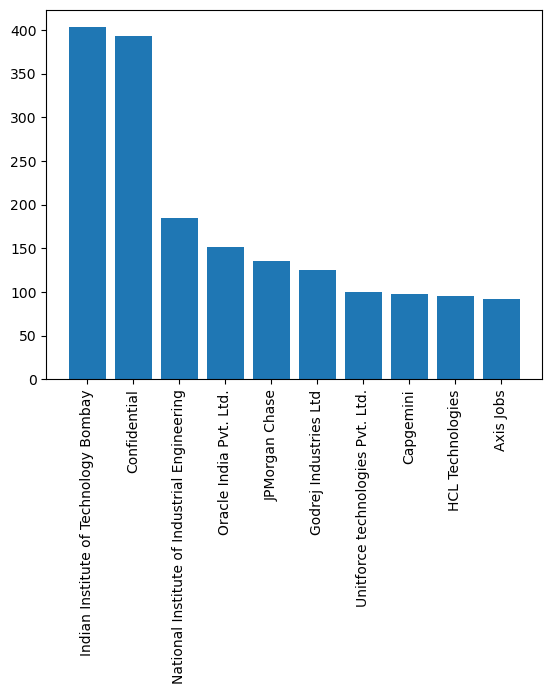

In [315]:
plt.bar(company_df['company_name'][0:10] , company_df['number of jobs'][0:10]) # x, y axis
plt.xticks(rotation=90)

([<matplotlib.patches.Wedge at 0x1d2f4b75e20>,
 [Text(0.8324234194600029, 0.7190766654081582, 'Indian Institute of Technology Bombay'),
  Text(-0.573960615708053, 0.9383864937306124, 'Confidential'),
  Text(-1.0999999999999988, -5.149471622296949e-08, 'National Institute of Industrial Engineering'),
  Text(-0.9115665532812928, -0.6156674580801427, 'Oracle India Pvt. Ltd.'),
  Text(-0.4993028488902041, -0.9801513480530066, 'JPMorgan Chase'),
  Text(-0.012640258569136401, -1.099927372085678, 'Godrej Industries Ltd'),
  Text(0.4144303009088497, -1.0189443192287793, 'Unitforce technologies Pvt. Ltd.'),
  Text(0.7387374283097998, -0.8150257738343146, 'Capgemini'),
  Text(0.968878835951142, -0.5208395158260941, 'HCL Technologies'),
  Text(1.0854820524595792, -0.17812555624654056, 'Axis Jobs')])

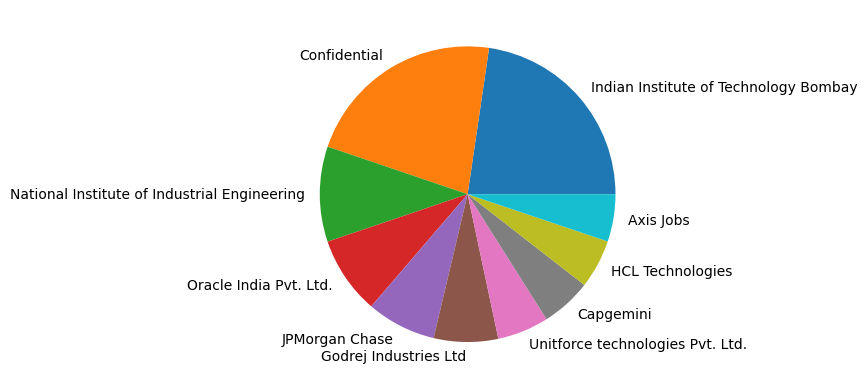

In [316]:
plt.pie(labels=company_df['company_name'][0:10] , x= company_df['number of jobs'][0:10]) 

#### Writing a function to plot above charts

In [317]:
def perform_analysis(data, feature, col1, col2, chart):
    '''
    This will return us plot depending upon whatever chart we want.

    Parameters:
    ----------
    
    data: dataframe
    feature: column_name that we have to consider for analysis
    col1: 1st column name that you want to assign to new df
    col2: 2nd column name that you want to assign to new df
    chart: if its value is 1, it represents bar chart, 
            if its value is 2, it represents pie chart
    '''
    dataframe= data[feature].value_counts().reset_index()
    dataframe.columns = [col1, col2]

    if chart==1:
        plt.bar(dataframe[col1][0:10] , dataframe[col2][0:10]) # x, y axis
        plt.xticks(rotation=90)
    elif chart==2:
        plt.pie(labels=dataframe[col1][0:10] , x=dataframe[col2][0:10]) 
    

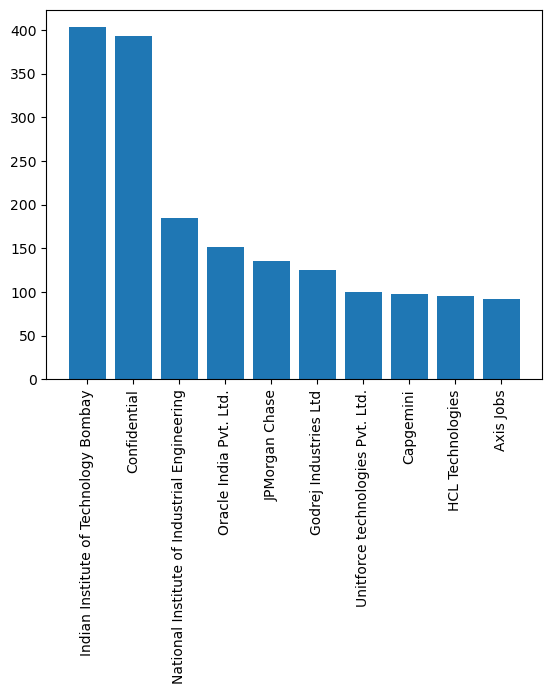

In [318]:
perform_analysis(df,'company', 'company_name', 'no of jobs', 1)

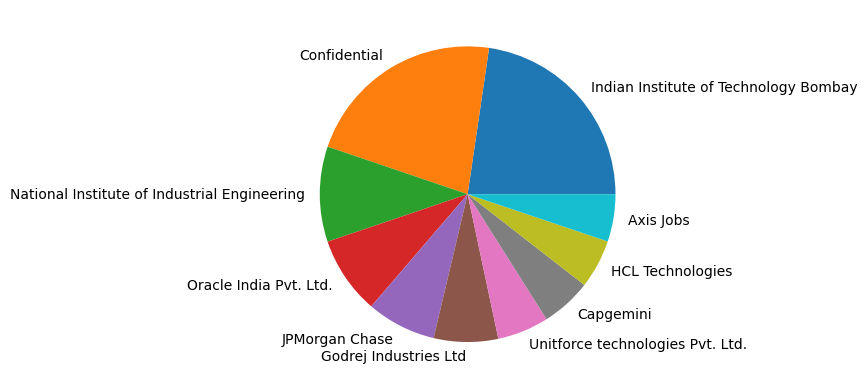

In [319]:
perform_analysis(df,'company', 'company_name', 'no of jobs', 2)

In [320]:
print(perform_analysis.__doc__) # Showing my documentation for that function


    This will return us plot depending upon whatever chart we want.

    Parameters:
    ----------
    
    data: dataframe
    feature: column_name that we have to consider for analysis
    col1: 1st column name that you want to assign to new df
    col2: 2nd column name that you want to assign to new df
    chart: if its value is 1, it represents bar chart, 
            if its value is 2, it represents pie chart
    


In [321]:
print(pd.read_csv.__doc__)


Read a comma-separated values (csv) file into DataFrame.

Also supports optionally iterating or breaking of the file
into chunks.

Additional help can be found in the online docs for
`IO Tools <https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html>`_.

Parameters
----------
filepath_or_buffer : str, path object or file-like object
    Any valid string path is acceptable. The string could be a URL. Valid
    URL schemes include http, ftp, s3, gs, and file. For file URLs, a host is
    expected. A local file could be: file://localhost/path/to/table.csv.

    If you want to pass in a path object, pandas accepts any ``os.PathLike``.

    By file-like object, we refer to objects with a ``read()`` method, such as
    a file handle (e.g. via builtin ``open`` function) or ``StringIO``.
sep : str, default ','
    Character or regex pattern to treat as the delimiter. If ``sep=None``, the
    C engine cannot automatically detect
    the separator, but the Python parsing engine can, mea

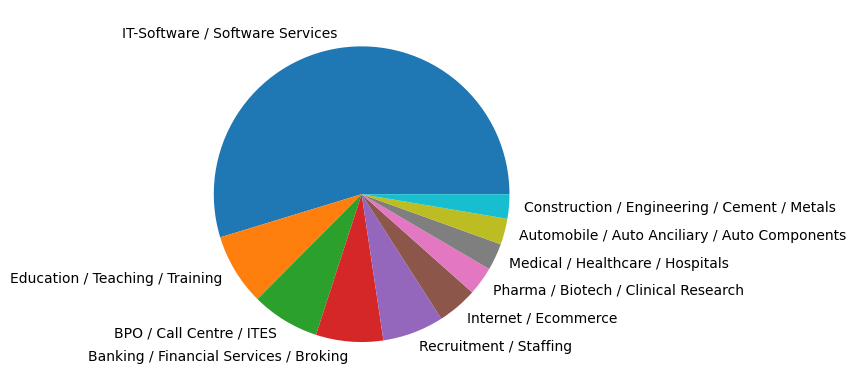

In [322]:
perform_analysis(df,'industry', 'industry_name', 'no of jobs', 2)

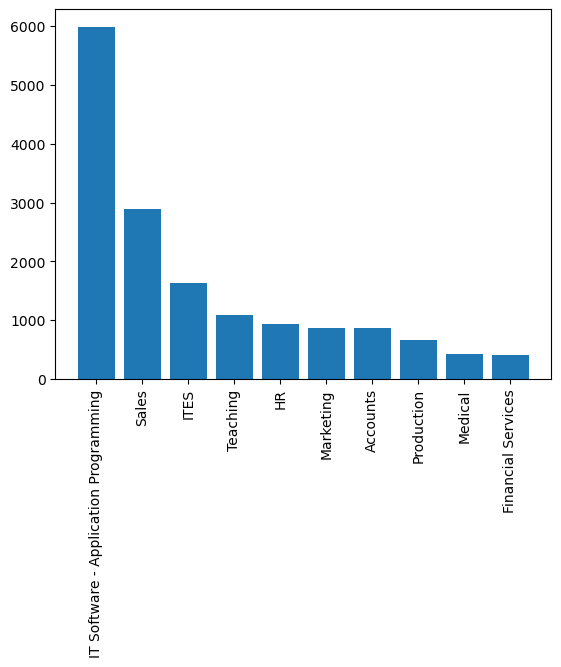

In [323]:
perform_analysis(df,'skills', 'skill_name', 'no of jobs', 1)

#### Relation between Experience and Payrate

In [326]:
df2['min_exp'].corr(df2['min_pay'])

0.5809950260316303

In [329]:
df2['avg_pay'].corr(df2['avg_exp'])

0.7113446697062643

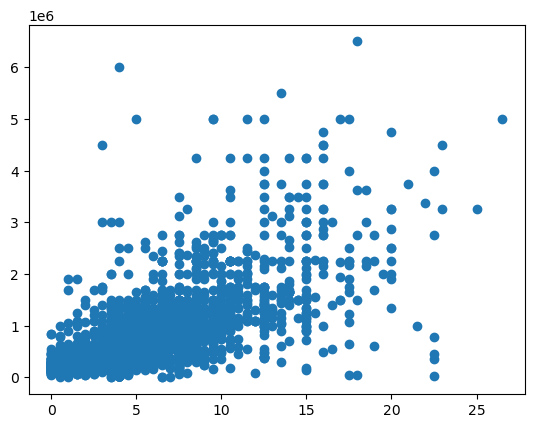

In [330]:
plt.scatter(df2['avg_exp'], df2['avg_pay'])

<Axes: xlabel='min_exp', ylabel='min_pay'>

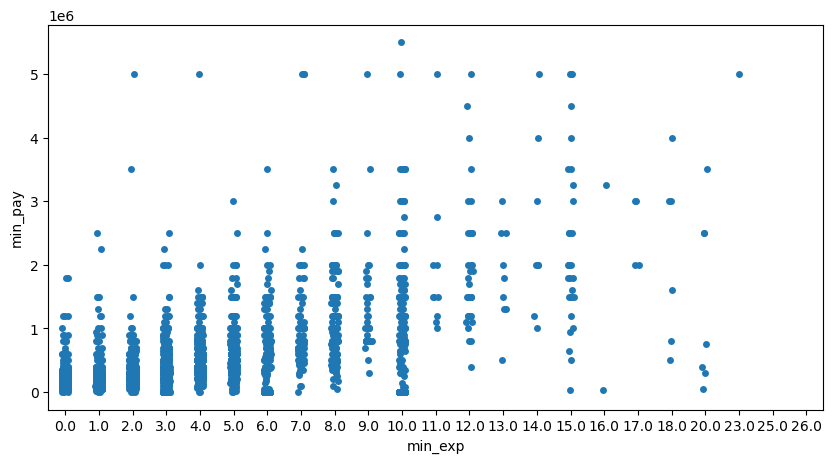

In [331]:
plt.figure(figsize=(10,5))
sns.stripplot(x='min_exp', y='min_pay', data=df2)

<Axes: xlabel='min_exp', ylabel='min_pay'>

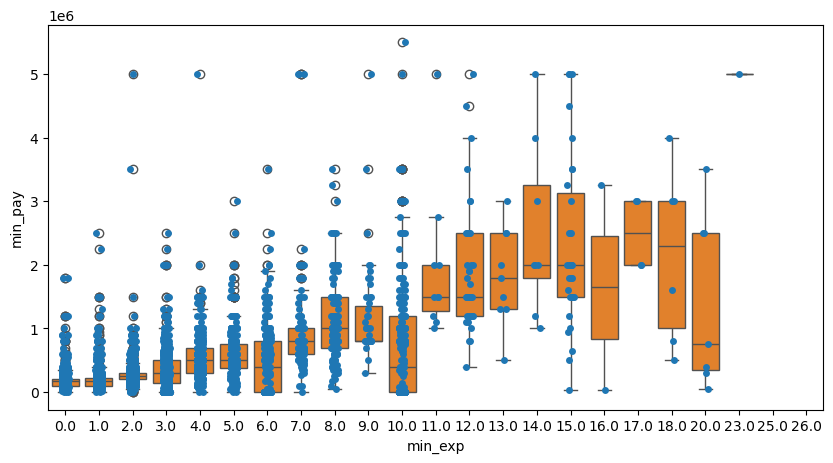

In [337]:
plt.figure(figsize=(10,5))
sns.stripplot(x='min_exp', y='min_pay', data=df2)
sns.boxplot(x='min_exp', y='min_pay', data=df2)

#### In strip plot:
##### X-axis (or Y): Categorical
##### Y-axis (or X): Continuous

#### In scatter plot:
##### Both axis are continuous

<Axes: xlabel='max_exp', ylabel='max_pay'>

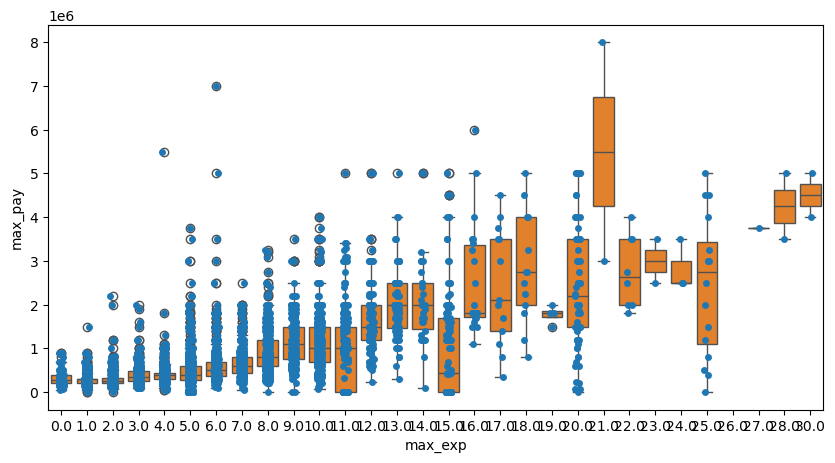

In [338]:
plt.figure(figsize=(10,5))
sns.stripplot(x='max_exp', y='max_pay', data=df2)
sns.boxplot(x='max_exp', y='max_pay', data=df2)

#### Find median max_pay in different industries

In [351]:
df[['industry','max_pay']].groupby(['industry']).median()

,max_pay
industry,
Accounting / Finance,600000.0
Advertising / PR / MR / Event Management,500000.0
Agriculture / Dairy,325000.0
Animation / Gaming,287500.0
Architecture / Interior Design,412500.0
...,...
Travel / Hotels / Restaurants / Airlines / Railways,400000.0
Tyres,900000.0
Water Treatment / Waste Management,800000.0


In [353]:
df[['industry','max_pay']].groupby(['industry']).median().sort_values(by='max_pay',ascending=False).head(10) # Showing top 10

,max_pay
industry,
Pulp and Paper,1312500.0
Strategy / Management Consulting Firms,1200000.0
Glass / Glassware,1025000.0
Telecom/ISP,950000.0
Tyres,900000.0
Ceramics / Sanitary ware,900000.0
IT-Software / Software Services,800000.0
Aviation / Aerospace Firms,800000.0
Water Treatment / Waste Management,800000.0


<Axes: xlabel='industry'>

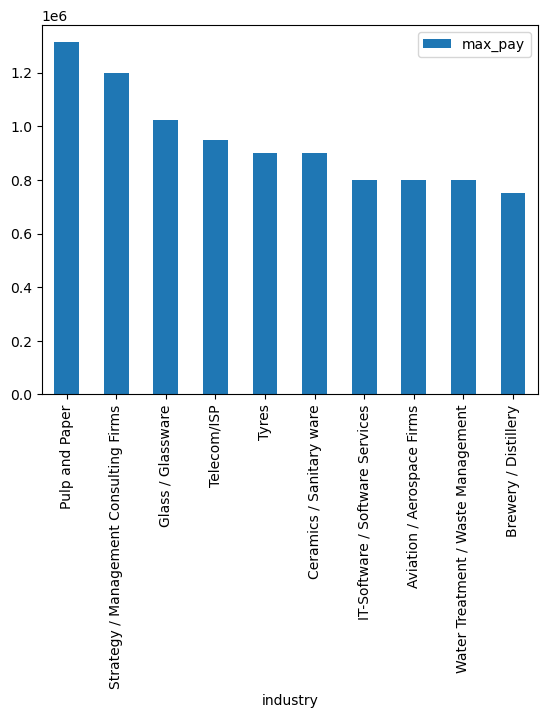

In [354]:
df[['industry','max_pay']].groupby(['industry']).median().sort_values(by='max_pay',ascending=False).head(10).plot(kind="bar")

#### Find the skill that has max_pay

In [369]:
# df[['skills', 'max_pay']].groupby("skills").max().sort_values(by="max_pay", ascending=False).head(1)
df.groupby(["skills"])["max_pay"].max().reset_index().sort_values(by="max_pay", ascending=False).head(1)

,skills,max_pay
0,Accounts,8000000.0


In [363]:
df[df['max_pay']==df['max_pay'].max()]

,company,education,industry,jobdescription,jobid,joblocation_address,jobtitle,numberofpositions,site_name,skills,min_pay,max_pay,min_exp,max_exp,avg_pay,avg_exp,day,month,year
1326,V- Konnect Associates,PG:CA,Retail / Wholesale,Job Description Send me Jobs like this a. CA...,60716005074,Bengaluru,CFO,NaN,NaN,Accounts,5000000.0,8000000.0,15.0,21.0,6500000.0,18.0,7.0,10.0,2016.0


#### Analyze the available positions in industry

In [375]:
df.groupby("industry")["numberofpositions"].sum().reset_index().sort_values(by="numberofpositions",ascending=False).head(5)

,industry,numberofpositions
7,BPO / Call Centre / ITES,90777.0
38,Medical / Healthcare / Hospitals,40755.0
29,IT-Software / Software Services,21180.0
58,Travel / Hotels / Restaurants / Airlines / Rai...,10421.0
44,Pharma / Biotech / Clinical Research,10253.0


<Axes: ylabel='numberofpositions'>

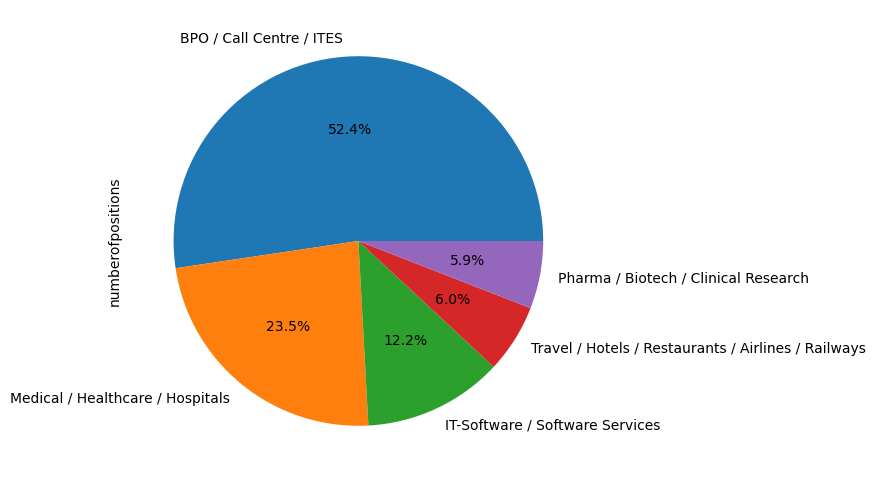

In [378]:
plt.figure(figsize=(10,6))
df.groupby("industry")["numberofpositions"].sum().sort_values(ascending=False).head(5).plot(kind="pie", autopct='%1.1f%%')